In [24]:
%load_ext autoreload
%autoreload 2

import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style, FS_ANNOT_LG, FS_ANNOT_SM
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.core.model_engine_mixed import NormativeModelEngineMixed
from MixedEffectsModeling.core.ood_filter import MahalanobisFilter, RangeFilter
from MixedEffectsModeling.core.shash import load_shash_params, shash_correct_matrix
from MixedEffectsModeling.validation.lobo_engine import load_full_data

ZDIR = config.ZSCORES_MIXED_DIR
FIGDIR = config.DISEASE_SCORING_FIG_DIR
FIGDIR.mkdir(parents=True, exist_ok=True)
ZDIR.mkdir(parents=True, exist_ok=True)

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
# 0. Load production engine + disease covariates/counts (non-HC rows of the same QC-filtered cohort LOBO uses)
engine = NormativeModelEngineMixed.load(config.ENGINE_MIXED_DIR)
gene_names = [g for g in engine.genes if engine.genes[g].ok]

data = load_full_data()
dis_idx = np.where(~data['is_hc'])[0]
X_dis = data['X_raw'][dis_idx]
Y_dis = data['Y'][dis_idx][:, [data['gene_col'][g] for g in gene_names]]
names_dis = data['names'][dis_idx]
batch_dis = data['batch'][dis_idx]
phenotype_dis = data['phenotype'][dis_idx]

print(f"engine genes (ok): {len(gene_names)}")
print(f"disease samples: {len(dis_idx)}")
print(pd.Series(phenotype_dis).value_counts())

engine genes (ok): 19851
disease samples: 913
CAD_HF+               116
CAD_HF-               108
Tuberculosis          103
ME/CFS                 90
Pancreatitis           81
Pancreatic Cancer      74
Pre-eclampsia          62
Liver Cancer           48
Colorectal Cancer      41
Lung Cancer            33
Stomach Cancer         29
Esophagus Cancer       27
MM                     18
Other Cancer           18
HIV                    13
HIV + Tuberculosis     11
ICI-m                  11
ICI-treated Cancer     11
MGUS                    8
Pancreatic Cancer       6
Liver Cirrhosis         5
Name: count, dtype: int64


In [26]:
hc_train_mask = data['is_hc'] & ~np.isin(data['batch'], list(data['small_hc_batches']))
X_hc = data['X_raw'][hc_train_mask]

ood = MahalanobisFilter(percentile=95).fit(X_hc)
mahal_dist = ood.distances(X_dis)
mahal_keep = mahal_dist <= ood.threshold_
rng_filter = RangeFilter(n_out_thr=2).fit(X_hc)
n_out = rng_filter.n_out(X_dis)
range_keep = rng_filter.mask(X_dis)

ood_keep = mahal_keep & range_keep

summary = (pd.DataFrame({'phenotype': phenotype_dis, 'keep': ood_keep})
          .groupby('phenotype')['keep']
          .agg(n_total='size', n_kept='sum')
          .assign(pct_removed=lambda d: (1 - d['n_kept'] / d['n_total']) * 100)
          .sort_values('pct_removed', ascending=False))
print(f"Mahalanobis P95 threshold: {ood.threshold_:.2f}  (flagged {int((~mahal_keep).sum())})")
print(f"Range filter (>={rng_filter.n_out_thr} axes outside HC p1-p99): flagged {int((~range_keep).sum())}")
print(f"combined: kept {ood_keep.sum()}/{len(ood_keep)} ({(~ood_keep).mean()*100:.1f}% flagged OOD)")
print(summary.to_string())

Mahalanobis P95 threshold: 5.18  (flagged 51)
Range filter (>=2 axes outside HC p1-p99): flagged 54
combined: kept 832/913 (8.9% flagged OOD)
                    n_total  n_kept  pct_removed
phenotype                                       
Pancreatic Cancer         6       2    66.666667
Stomach Cancer           29      21    27.586207
Lung Cancer              33      26    21.212121
Liver Cirrhosis           5       4    20.000000
ICI-treated Cancer       11       9    18.181818
Colorectal Cancer        41      34    17.073171
Liver Cancer             48      40    16.666667
CAD_HF+                 116     101    12.931034
CAD_HF-                 108      96    11.111111
Other Cancer             18      16    11.111111
HIV + Tuberculosis       11      10     9.090909
ICI-m                    11      10     9.090909
Esophagus Cancer         27      25     7.407407
Pre-eclampsia            62      58     6.451613
MM                       18      17     5.555556
Pancreatic Cancer        

21 phenotypes, 913 disease samples scored
                    n_total  n_kept
phenotype                          
Pancreatic Cancer         6       2
Stomach Cancer           29      21
Lung Cancer              33      26
Liver Cirrhosis           5       4
ICI-treated Cancer       11       9
Colorectal Cancer        41      34
Liver Cancer             48      40
CAD_HF+                 116     101
CAD_HF-                 108      96
Other Cancer             18      16
HIV + Tuberculosis       11      10
ICI-m                    11      10
Esophagus Cancer         27      25
Pre-eclampsia            62      58
MM                       18      17
Pancreatic Cancer        74      72
Pancreatitis             81      79
Tuberculosis            103     101
HIV                      13      13
MGUS                      8       8
ME/CFS                   90      90


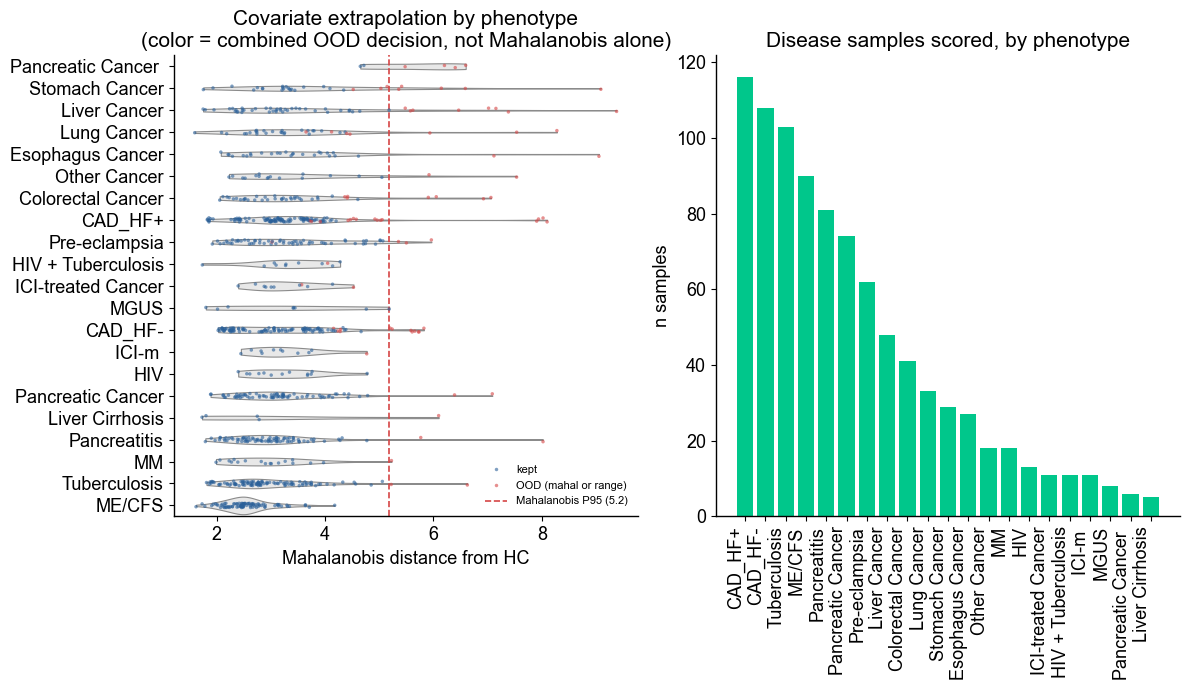

In [27]:
print(f"{summary.shape[0]} phenotypes, {len(phenotype_dis)} disease samples scored")
print(summary[['n_total', 'n_kept']].to_string())

vio = pd.DataFrame({'phenotype': phenotype_dis, 'mahal_dist': mahal_dist, 'n_out': n_out,
                    'flag': np.where(ood_keep, 'kept', 'OOD (mahal or range)')})
order_mahal = vio.groupby('phenotype')['mahal_dist'].mean().sort_values(ascending=False).index
order_count = summary.sort_values('n_total', ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# violin shows the Mahalanobis axis, but point color is the COMBINED decision (mahal OR range) --
# a point can sit left of the Mahalanobis line and still be red if the range filter caught it
sns.violinplot(data=vio, y='phenotype', x='mahal_dist', order=order_mahal,
               color='#e8e8e8', orient='h', cut=0, inner=None, linewidth=0.8, ax=axes[0])
sns.stripplot(data=vio, y='phenotype', x='mahal_dist', order=order_mahal, hue='flag',
              hue_order=['kept', 'OOD (mahal or range)'], palette=['#2a6099', '#d64545'],
              orient='h', size=2.5, alpha=0.6, jitter=True, ax=axes[0])
axes[0].axvline(ood.threshold_, color='#d64545', ls='--', lw=1.2, label=f'Mahalanobis P95 ({ood.threshold_:.1f})')
axes[0].set_xlabel('Mahalanobis distance from HC')
axes[0].set_ylabel('')
axes[0].set_title('Covariate extrapolation by phenotype\n(color = combined OOD decision, not Mahalanobis alone)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, frameon=False, fontsize=FS_ANNOT_SM, loc='lower right')

axes[1].bar(range(len(order_count)), summary.loc[order_count, 'n_total'], color='#00C78B')
axes[1].set_xticks(range(len(order_count)))
axes[1].set_xticklabels(order_count, rotation=90, ha='right')
axes[1].set_ylabel('n samples')
axes[1].set_title('Disease samples scored, by phenotype')

plt.tight_layout()
fig.savefig(FIGDIR / 'phenotype_summary.png', bbox_inches='tight')

In [28]:
# 1. Score (raw RQR) -- cache-first
Z_CAP = 10.0  # |Z| beyond this is already p~1e-23 -- clip only tames the axis, doesn't change BH calls
Z_PATH = ZDIR / 'Z_disease.npy'
GENES_PATH = ZDIR / 'gene_names.pkl'
META_PATH = ZDIR / 'sample_meta.csv'

if Z_PATH.exists():
    Z = np.load(Z_PATH)
else:
    Z = np.clip(engine.score(X_dis, Y_dis, gene_names=gene_names), -Z_CAP, Z_CAP)
    np.save(Z_PATH, Z)
    with open(GENES_PATH, 'wb') as f:
        pickle.dump(gene_names, f)

pd.DataFrame({'sample': names_dis, 'batch': batch_dis, 'phenotype': phenotype_dis,
             'ood_keep': ood_keep, 'mahal_dist': mahal_dist, 'n_out': n_out}).to_csv(META_PATH, index=False)

print(f"Z shape: {Z.shape}, finite frac: {np.isfinite(Z).mean():.4f}, max |Z|: {np.nanmax(np.abs(Z)):.2f}")

Z shape: (913, 19851), finite frac: 1.0000, max |Z|: 7.94


In [29]:
# 2. SHASH-correct -- cache-first
Z_SHASH_PATH = ZDIR / 'Z_disease_shash.npy'

# loaded outside the cache branch: cell 2b needs it even when this matrix comes from disk
shash_params = load_shash_params(config.ENGINE_MIXED_DIR / 'training_summary.csv')  # engine's own in-sample SHASH fit, see model_engine_mixed.NormativeModelEngineMixed.fit_shash

if Z_SHASH_PATH.exists():
    Z_shash = np.load(Z_SHASH_PATH)
else:
    Z_shash = shash_correct_matrix(np.nan_to_num(Z, nan=0.0, posinf=10.0, neginf=-10.0), gene_names, shash_params)
    Z_shash = np.clip(Z_shash, -Z_CAP, Z_CAP)
    Z_shash[~np.isfinite(Z)] = np.nan
    np.save(Z_SHASH_PATH, Z_shash)

print(f"Z_shash shape: {Z_shash.shape}")
print(f"mean |Z| raw vs shash: {np.nanmean(np.abs(Z)):.4f} vs {np.nanmean(np.abs(Z_shash)):.4f}")
print(f"max |Z_shash|: {np.nanmax(np.abs(Z_shash)):.2f}")

Z_shash shape: (913, 19851)
mean |Z| raw vs shash: 0.8503 vs 0.8633
max |Z_shash|: 10.00


In [30]:
# 2b. In-sample HC Z (production null, used by fit_shash internally but never persisted) -- cache-first
HC_Z_PATH = ZDIR / 'Z_hc.npy'
HC_Z_SHASH_PATH = ZDIR / 'Z_hc_shash.npy'
HC_META_PATH = ZDIR / 'hc_meta.csv'

names_hc = data['names'][hc_train_mask]
batch_hc_names = data['batch'][hc_train_mask]
Y_hc = data['Y'][hc_train_mask][:, [data['gene_col'][g] for g in gene_names]]

if HC_Z_SHASH_PATH.exists():
    Z_hc_shash = np.load(HC_Z_SHASH_PATH)
else:
    Z_hc = np.clip(engine.score(X_hc, Y_hc, gene_names=gene_names), -Z_CAP, Z_CAP)
    np.save(HC_Z_PATH, Z_hc)
    Z_hc_shash = shash_correct_matrix(np.nan_to_num(Z_hc, nan=0.0, posinf=10.0, neginf=-10.0), gene_names, shash_params)
    Z_hc_shash = np.clip(Z_hc_shash, -Z_CAP, Z_CAP)
    Z_hc_shash[~np.isfinite(Z_hc)] = np.nan
    np.save(HC_Z_SHASH_PATH, Z_hc_shash)
    pd.DataFrame({'sample': names_hc, 'batch': batch_hc_names}).to_csv(HC_META_PATH, index=False)

print(f"Z_hc_shash shape: {Z_hc_shash.shape}, finite frac: {np.isfinite(Z_hc_shash).mean():.4f}")
print(f"HC marginal: mean={np.nanmean(Z_hc_shash):.4f} std={np.nanstd(Z_hc_shash):.4f}")

Z_hc_shash shape: (679, 19851), finite frac: 1.0000
HC marginal: mean=-0.0002 std=0.9997


In [31]:
from scipy.stats import norm

from MixedEffectsModeling.core.calibration import bh_fdr_reject
FDR_Q = 0.05

# per-sample BH-significant gene count + critical p-value, cache-first
SIG_PATH = ZDIR / 'sample_bh_sig.csv'
if SIG_PATH.exists():
    sig_df = pd.read_csv(SIG_PATH)
else:
    p_all = 2 * norm.sf(np.abs(Z_shash))
    n_sig = np.zeros(len(names_dis), dtype=int)
    p_thr = np.full(len(names_dis), np.nan)
    for i in range(len(names_dis)):
        row = p_all[i]
        row = row[np.isfinite(row)]
        if len(row) == 0:
            continue
        reject = bh_fdr_reject(row, q=FDR_Q)
        n_sig[i] = int(reject.sum())
        if reject.any():
            p_thr[i] = float(row[reject].max())
    sig_df = pd.DataFrame({'sample': names_dis, 'phenotype': phenotype_dis, 'ood_keep': ood_keep,
                           'n_sig': n_sig, 'p_thr': p_thr})
    sig_df.to_csv(SIG_PATH, index=False)

top = sig_df[sig_df['ood_keep']].sort_values('n_sig', ascending=False).head(20)
print(top[['sample', 'phenotype', 'n_sig', 'p_thr']].to_string(index=False))

     sample         phenotype  n_sig    p_thr
SRR14506728      Liver Cancer   1381 0.003464
SRR14506735      Liver Cancer   1324 0.003335
SRR14506777    Stomach Cancer   1103 0.002770
SRR14506802 Colorectal Cancer    967 0.002434
SRR33475188            ICI-m     899 0.002264
SRR33475193            ICI-m     797 0.002005
SRR14506707       Lung Cancer    772 0.001943
SRR14506801 Colorectal Cancer    766 0.001927
SRR14506768    Stomach Cancer    697 0.001755
SRR14506706       Lung Cancer    681 0.001711
SRR15619011                MM    619 0.001540
SRR29803958 Pancreatic Cancer    607 0.001524
SRR33475189            ICI-m     557 0.001403
SRR15619009                MM    372 0.000934
SRR29804042 Pancreatic Cancer    363 0.000912
SRR14506720       Lung Cancer    361 0.000907
SRR28476480               HIV    358 0.000890
SRR14506705       Lung Cancer    358 0.000884
SRR14506693       Lung Cancer    357 0.000897
SRR29804066      Pancreatitis    336 0.000841


In [32]:
import scanpy as sc

CHROM_ORDER = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY', 'chrM']
chrom_rank = {c: i for i, c in enumerate(CHROM_ORDER)}

var = sc.read_h5ad(config.H5AD_PATH, backed='r').var.loc[gene_names, ['Chromosome']].copy()
var['rank'] = var['Chromosome'].map(chrom_rank).astype(float).fillna(len(CHROM_ORDER))
var = var.sort_values('rank', kind='stable')  # stable: keeps var's own (genomic-proxy) order within a chromosome
var['x'] = range(len(var))

gene_x = var['x'].to_dict()
x_pos = np.array([gene_x[g] for g in gene_names])
chrom_of = var['Chromosome']
tick_df = var.groupby('Chromosome')['x'].median().reindex([c for c in CHROM_ORDER if c in var['Chromosome'].values])
tick_x = tick_df.values
tick_lab = [c.replace('chr', '') for c in tick_df.index]

/tmp/ipykernel_129354/2890160353.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tick_df = var.groupby('Chromosome')['x'].median().reindex([c for c in CHROM_ORDER if c in var['Chromosome'].values])


In [33]:
import json

REF_DIR = config.DISEASE_REF_DIR
MARKER_TOPN = 500
MARKER_SCORE_FLOOR = 0.01

sym_of = sc.read_h5ad(config.H5AD_PATH, backed='r').var['GeneName'].reindex(gene_names)
sym2cols = {}
for j, sym in enumerate(sym_of.values):
    sym2cols.setdefault(sym, []).append(j)

pheno_markers = {}
pheno_scores = {}  # sym -> OT association score, drives both label ranking and sample ranking below
for f in REF_DIR.glob('*.json'):
    rec = json.load(open(f))
    if rec['phenotype'] == 'MGUS':  # OT association pool too thin (22 genes) for any panel size
        continue
    ranked = sorted(rec['genes'], key=lambda gs: -gs[1])
    floored = [g for g, s in ranked if s >= MARKER_SCORE_FLOOR]
    genes = set(floored[:MARKER_TOPN]) | set(rec.get('supplement', {}).get('genes', []))
    pheno_markers[rec['phenotype']] = genes
    pheno_scores[rec['phenotype']] = dict(rec['genes'])

p_all = 2 * norm.sf(np.abs(Z_shash))
phenotype_stripped = pd.Series(phenotype_dis).str.strip().values
p_thr_of = sig_df.set_index('sample')['p_thr']
n_sig_of = sig_df.set_index('sample')['n_sig']  # genome-wide BH-significant gene count, not just markers

rows = []
for i, (name, ph) in enumerate(zip(names_dis, phenotype_stripped)):
    markers = pheno_markers.get(ph)
    scores = pheno_scores.get(ph, {})
    p_thr = p_thr_of.get(name, np.nan)
    marker_cols = sorted({j for sym in (markers or []) for j in sym2cols.get(sym, [])})
    hit_syms = ([] if not marker_cols or not np.isfinite(p_thr)
                else sorted({sym_of.iloc[j] for j in marker_cols if p_all[i, j] <= p_thr}))
    hit_scores = [scores.get(s, 0.0) for s in hit_syms]
    rows.append((name, ph, ood_keep[i], len(marker_cols), len(hit_syms), ';'.join(hit_syms), int(n_sig_of.get(name, 0)),
                float(np.sum(hit_scores)), float(np.mean(hit_scores)) if hit_scores else 0.0))

marker_df = pd.DataFrame(rows, columns=['sample', 'phenotype', 'ood_keep', 'n_markers_tested',
                                        'n_markers_sig', 'marker_genes_sig', 'n_sig_genome',
                                        'marker_score_sum', 'marker_score_mean'])
marker_df['frac_markers_sig'] = marker_df['n_markers_sig'] / marker_df['n_markers_tested'].replace(0, np.nan)
marker_df.to_csv(ZDIR / 'sample_marker_hits.csv', index=False)

print(marker_df.groupby('phenotype').agg(
    n_samples=('sample', 'size'), n_markers=('n_markers_tested', 'first'),
    mean_n_sig_genome=('n_sig_genome', 'mean'), mean_frac_sig=('frac_markers_sig', 'mean')).to_string())
marker_df[marker_df['ood_keep'] & (marker_df['n_markers_tested'] > 0)].sort_values(
    'marker_score_sum', ascending=False).head(15)

                    n_samples  n_markers  mean_n_sig_genome  mean_frac_sig
phenotype                                                                 
CAD_HF+                   116          0          29.698276            NaN
CAD_HF-                   108          0          23.027778            NaN
Colorectal Cancer          41        501         201.170732       0.016260
Esophagus Cancer           27        499          38.444444       0.001707
HIV                        13        500         103.615385       0.007231
HIV + Tuberculosis         11        486          27.818182       0.002432
ICI-m                      11          0         483.727273            NaN
ICI-treated Cancer         11          0          52.363636            NaN
Liver Cancer               48        500         350.354167       0.021875
Liver Cirrhosis             5        496         288.800000       0.014919
Lung Cancer                33        502         302.000000       0.016178
ME/CFS                   

,sample,phenotype,ood_keep,n_markers_tested,n_markers_sig,marker_genes_sig,n_sig_genome,marker_score_sum,marker_score_mean,frac_markers_sig
61,SRR14506728,Liver Cancer,True,500,70,ABI1;ARNT;ASXL1;ATM;BCL10;BRD4;CARD11;CBFA2T3;...,1381,23.9070,0.341529,0.140000
114,SRR14506802,Colorectal Cancer,True,501,37,ASXL1;BAX;BLM;BRCA1;BTG1;CCNB1IP1;CCND1;CDKN1B...,967,17.9265,0.484500,0.073852
113,SRR14506801,Colorectal Cancer,True,501,33,BTG1;CARD11;CASP8;CIITA;CSF3R;DDX3X;DNMT3A;ELF...,766,15.5212,0.470339,0.065868
585,SRR29803958,Pancreatic Cancer,True,500,36,ABI1;AMER1;ARHGAP26;BCL2;BRD3;BRD4;BTK;CALR;CU...,607,13.4245,0.372903,0.072000
93,SRR14506777,Stomach Cancer,True,501,26,AFF4;ALK;APC;ATF1;ATM;ATP4B;CDKN2C;CDX2;CYLD;F...,1103,11.5651,0.444812,0.051896
67,SRR14506735,Liver Cancer,True,500,30,ALK;APC;ARID1B;BCORL1;BLM;CDKN2A;CDKN2C;FANCE;...,1324,11.1559,0.371863,0.060000
42,SRR14506706,Lung Cancer,True,502,17,CACNA1D;CARS1;CHEK2;CIC;CXCR4;ERCC4;GART;MRTFA...,681,9.2836,0.546094,0.033865
86,SRR14506768,Stomach Cancer,True,501,21,ATM;BAP1;BCORL1;CDC73;CDKN2C;CIC;DPYD;DROSHA;F...,697,9.2826,0.442029,0.041916
158,SRR15619011,MM,True,499,27,AKT2;ATRX;BAK1;BARD1;BRCA1;BUB1B;CCNB1IP1;CD79...,619,8.9882,0.332896,0.054108
41,SRR14506705,Lung Cancer,True,502,16,ATF1;ATRX;BLM;DROSHA;ELL;IDH2;MLH1;NDRG1;NSD3;...,358,7.9561,0.497256,0.031873


In [ ]:
# 3. Curation for the Manhattan panels -- two independent axes, top-N each, pancreatic only,
#    OOD-filtered. Both axes score hits at CURATE_Q (the loosest tier the panels draw) and weight
#    each hit by its evidence strength -log10(p), so a sample ranks on how strongly its panel
#    genes deviate, not only on how many of them clear the cut.
#    A (cancer): Open Targets association score x -log10(p).
#    B (cell):   PanglaoDB pancreas cell-type panel (marker_panels.py), -log10(p) alone.
from MixedEffectsModeling.marker_panels import panel_table

CURATE_N = 4
CURATE_Q = 0.20  # same tier the Manhattan panels draw, so selection and figure agree
CELL_MIN_DETECT = 0.10  # RQR on near-zero counts fires |Z|>1.96 at ~5%; filter before counting hits
PANC_PHENOTYPES = ['Pancreatic Cancer', 'Pancreatitis']
PANC_STUDY = 'Moore et al.'  # Stage/Condition holds histology for Moore but TNM stage for
                             # Reggiardo, and Reggiardo reports no histology at all -- mixing
                             # them would put "stage III" on the same axis as "PDAC".

_obs = sc.read_h5ad(config.H5AD_PATH, backed='r').obs
stage_of = _obs['Stage/Condition'].astype(str)
tstage_of = pd.to_numeric(_obs['Tumor_Stage'], errors='coerce')
is_panc = np.isin(phenotype_stripped, PANC_PHENOTYPES) & pd.Series(batch_dis).str.startswith(PANC_STUDY).values
panc = is_panc & ood_keep
print(f"{PANC_STUDY} pancreatic: {is_panc.sum()} of {np.isin(phenotype_stripped, PANC_PHENOTYPES).sum()} "
      f"pancreatic, {panc.sum()} after the OOD filter")

panel = panel_table(gene_names, sym_of)
panel['detect_frac'] = (Y_dis[panc] > 0).mean(axis=0)[panel['col'].values]
panel_ok = panel[panel['detect_frac'] >= CELL_MIN_DETECT].reset_index(drop=True)
print(f"pancreas panel: {len(panel)} modeled genes, {len(panel_ok)} with detect_frac >= {CELL_MIN_DETECT}")
print(panel_ok.groupby('set').size().to_string())

cancer_cols_of = {ph: sorted({j for sym in syms for j in sym2cols.get(sym, [])})
                  for ph, syms in pheno_markers.items()}
cell_cols = panel_ok['col'].values
cell_detect_of = dict(zip(panel_ok['symbol'], panel_ok['detect_frac']))
set_of_col = dict(zip(panel_ok['col'], panel_ok['set']))


def bh_crit_p(p, q):
    """Largest p BH rejects at q -- the cut this sample's genome-wide test actually applies."""
    pf = p[np.isfinite(p)]
    rej = bh_fdr_reject(pf, q=q)
    return float(pf[rej].max()) if rej.any() else np.nan


rows = []
for i in np.where(panc)[0]:
    thr = bh_crit_p(p_all[i], CURATE_Q)
    nlp = -np.log10(np.clip(p_all[i], 1e-300, 1))
    ot = pheno_scores.get(phenotype_stripped[i], {})
    c_hit = [] if not np.isfinite(thr) else [j for j in cancer_cols_of.get(phenotype_stripped[i], [])
                                             if p_all[i, j] <= thr]
    t_hit = [] if not np.isfinite(thr) else [j for j in cell_cols if p_all[i, j] <= thr]
    rows.append(dict(
        sample=names_dis[i], bh_crit_p=thr,
        n_cancer_sig=len(c_hit),
        cancer_score=float(sum(ot.get(sym_of.iloc[j], 0.0) * nlp[j] for j in c_hit)),
        cancer_genes_sig=';'.join(sorted({sym_of.iloc[j] for j in c_hit})),
        n_cell_sig=len(t_hit),
        cell_score=float(sum(nlp[j] for j in t_hit)),
        cell_sets=';'.join(sorted({set_of_col[j] for j in t_hit})),
        cell_genes_sig=';'.join(sorted({sym_of.iloc[j] for j in t_hit})),
        cell_detect_sum=float(sum(cell_detect_of[sym_of.iloc[j]] for j in t_hit))))
curate = pd.DataFrame(rows).set_index('sample')

curate = curate.join(marker_df.set_index('sample')[['phenotype', 'ood_keep', 'n_sig_genome']])
curate['stage'] = stage_of.reindex(curate.index).values
curate['tumor_stage'] = tstage_of.reindex(curate.index).values
curate.to_csv(ZDIR / 'pancreatic_curation.csv')

CURATED = []
seen = set()
for axis, key in [('cancer', 'cancer_score'), ('cell', 'cell_score')]:
    for s in curate.sort_values(key, ascending=False).index:
        n = sum(1 for _, a, _ in CURATED if a == axis)
        if n == CURATE_N:
            break
        if s in seen or curate.loc[s, key] <= 0:
            continue
        seen.add(s)
        CURATED.append((s, axis, n + 1))

print(f"\ncurated {len(CURATED)} samples ({CURATE_N} per axis at q<{CURATE_Q}, union):")
print(curate.loc[[s for s, _, _ in CURATED],
                 ['stage', 'tumor_stage', 'n_sig_genome', 'n_cancer_sig', 'cancer_score',
                  'n_cell_sig', 'cell_score', 'cell_sets']]
      .assign(axis=[f'{a}{r}' for _, a, r in CURATED]).to_string())


In [56]:
# 4. One Manhattan per curated sample. y is the UNCORRECTED per-gene p, so the four horizontal
#    lines show directly how much stricter BH is than a naive 0.05 cut. Point shading, q tiers
#    and the two panel colors match 6_pancreatic_cancer_cohort_deepdive's marker grids
#    (Open Targets cancer = blue, PanglaoDB tissue = red).
import matplotlib.colors as mcolors
from adjustText import adjust_text

Q_TIERS = [0.05, 0.10, 0.20]
TIER_BASE = '#B2182B'
MARKER_C = {'cancer': '#2166AC', 'tissue': '#B2182B'}
NAIVE_P = 0.05
MAX_LABELS = 24
THR_LABEL_GAP = 0.045  # min spacing between threshold labels, as a fraction of the y range
LABEL_MAX_MOVE = (18, 18)  # px a label may drift from its point -- caps the leader-line length
LEADER_PAD = 1.5           # px between the label box and where its leader line starts
LEADER_MIN = 4             # px: shorter than this and the label already sits on its point

SHADES = [mcolors.to_hex(1 - w + w * np.array(mcolors.to_rgb(TIER_BASE))) for w in (1.0, 0.66, 0.38)]
name2row = {n: i for i, n in enumerate(names_dis)}
chrom_idx = chrom_of.reindex(gene_names).astype(str).map(chrom_rank).fillna(len(CHROM_ORDER)).astype(int).values
chrom_color = np.where(chrom_idx % 2 == 0, '#5a5a5a', '#bdbdbd')

for sample, axis, rank in CURATED:
    row = curate.loc[sample]
    z = Z_shash[name2row[sample]]
    p = 2 * norm.sf(np.abs(np.nan_to_num(z)))
    p[~np.isfinite(z)] = np.nan
    neglog10p = -np.log10(np.clip(p, 1e-300, 1))

    crit = {q: bh_crit_p(p, q) for q in Q_TIERS}
    tier = np.zeros(len(gene_names), dtype=int)  # 1 = q<0.20 only ... 3 = q<0.05
    for lvl, q in enumerate(sorted(Q_TIERS, reverse=True), start=1):
        if np.isfinite(crit[q]):
            tier[p <= crit[q]] = lvl

    sets = {'cancer': cancer_cols_of.get(row['phenotype'], []), 'tissue': cell_cols}
    scores = {'cancer': pheno_scores.get(row['phenotype'], {}), 'tissue': cell_detect_of}
    # the two scores are not on a common scale, so label every tissue hit first and fill the
    # remaining slots with the top-scoring cancer hits
    ranked = {k: sorted([(j, k, tier[j], scores[k].get(sym_of.iloc[j], 0.0)) for j in cols if tier[j] > 0],
                        key=lambda t: (-t[2], -t[3])) for k, cols in sets.items()}
    labels = ranked['tissue'][:MAX_LABELS] + ranked['cancer'][:MAX_LABELS - len(ranked['tissue'])]
    n_hit = {k: len(v) for k, v in ranked.items()}

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(x_pos[tier == 0], neglog10p[tier == 0], c=chrom_color[tier == 0], s=4,
               alpha=0.5, edgecolors='none')
    for lvl, sh, sz in zip(range(len(Q_TIERS), 0, -1), SHADES, (10, 8, 6)):
        m = tier == lvl
        ax.scatter(x_pos[m], neglog10p[m], c=sh, s=sz, alpha=0.85, edgecolors='none', zorder=3)

    for j, kind, _, _ in labels:
        ax.scatter(x_pos[j], neglog10p[j], s=34, facecolors='none', edgecolors=MARKER_C[kind],
                   lw=0.9, zorder=5)

    lines = [(-np.log10(NAIVE_P), '#4D4D4D', ':', f'naive p < {NAIVE_P}')]
    lines += [(-np.log10(crit[q]), sh, '--', f'q < {q:.2f} thr')
              for q, sh in zip(sorted(Q_TIERS), SHADES) if np.isfinite(crit[q])]
    for y, c, ls, _ in lines:
        ax.axhline(y, color=c, ls=ls, lw=1.2, zorder=4)
    # margin labels, pushed apart: the four cuts sit within ~2 -log10 units of each other
    gap = THR_LABEL_GAP * (max(neglog10p[np.isfinite(neglog10p)]) - 0)
    ly = 0
    for y, c, _, lab in sorted(lines):
        ly = max(y, ly + gap) if ly else y
        ax.text(1.015, ly, lab, color=c, transform=ax.get_yaxis_transform(), ha='left',
                va='center', fontsize=FS_ANNOT_SM, clip_on=False, zorder=6)

    texts = [ax.text(x_pos[j], neglog10p[j], sym_of.iloc[j], color=MARKER_C[kind], zorder=7)
             for j, kind, _, _ in labels]
    if texts:
        adjust_text(texts, ax=ax, force_pull=(0.1, 0.1), max_move=LABEL_MAX_MOVE)
        # leader lines, always drawn (adjust_text only attaches an arrow to labels it moved) and
        # clipped at the label's bounding box so the line never runs under the text
        fig.canvas.draw()
        inv = ax.transData.inverted()
        for t, (j, kind, _, _) in zip(texts, labels):
            bb = t.get_window_extent()
            px, py = ax.transData.transform((x_pos[j], neglog10p[j]))
            cx, cy = bb.x0 + bb.width / 2, bb.y0 + bb.height / 2
            dx, dy = px - cx, py - cy
            sx = (bb.width / 2 + LEADER_PAD) / abs(dx) if dx else np.inf
            sy = (bb.height / 2 + LEADER_PAD) / abs(dy) if dy else np.inf
            f = min(sx, sy, 1.0)
            if np.hypot(dx, dy) * (1 - f) < LEADER_MIN:
                continue
            x0, y0 = inv.transform((cx + dx * f, cy + dy * f))
            ax.plot([x0, x_pos[j]], [y0, neglog10p[j]], color=MARKER_C[kind], lw=0.6,
                    alpha=0.8, zorder=6)

    ax.set_xticks(tick_x)
    ax.set_xticklabels(tick_lab, fontsize=FS_ANNOT_SM)
    ax.set_ylabel('-log10(p), uncorrected')
    tstage = '' if not np.isfinite(row['tumor_stage']) else f", T{int(row['tumor_stage'])}"
    ax.set_title(f"{sample} ({row['stage']}{tstage}) -- {axis} axis #{rank}\n"
                 f"{int(row['n_sig_genome'])} genes at q<{FDR_Q}; marker hits at q<{CURATE_Q:.2f}: "
                 f"{n_hit['cancer']} cancer (blue), {n_hit['tissue']} tissue (red)",
                 fontsize=FS_ANNOT_LG)
    ax.set_xlim(0, len(gene_names))
    fig.tight_layout()
    fig.savefig(FIGDIR / f'manhattan_{axis}{rank}_{sample}.png', bbox_inches='tight')
    print(f"{sample} {axis}{rank}: BH cut p " +
          " ".join(f"q{q:g}={crit[q]:.2e}" if np.isfinite(crit[q]) else f"q{q:g}=none" for q in Q_TIERS) +
          f" vs naive {NAIVE_P} | genes per tier 3/2/1 = "
          f"{int((tier==3).sum())}/{int((tier==2).sum())}/{int((tier==1).sum())}")


NameError: name 'cell_cols' is not defined

In [51]:
QS = [0.05, 0.10, 0.15, 0.20, 0.25]
SWEEP_SUMMARY_PATH = ZDIR / 'fdr_threshold_sweep_summary.csv'

if SWEEP_SUMMARY_PATH.exists():
    sweep_summary = pd.read_csv(SWEEP_SUMMARY_PATH)
else:
    p_all = 2 * norm.sf(np.abs(Z_shash))
    summary_rows = []
    for q in QS:
        tag = '' if q == FDR_Q else f'_q{q:g}'.replace('.', '')
        path = ZDIR / f'sample_bh_sig{tag}.csv'
        if path.exists():
            df_q = pd.read_csv(path)
        else:
            n_sig_q = np.zeros(len(names_dis), dtype=int)
            for i in range(len(names_dis)):
                row = p_all[i]
                row = row[np.isfinite(row)]
                if len(row) == 0:
                    continue
                n_sig_q[i] = int(bh_fdr_reject(row, q=q).sum())
            df_q = pd.DataFrame({'sample': names_dis, 'phenotype': phenotype_dis,
                                 'ood_keep': ood_keep, 'n_sig': n_sig_q})
            df_q.to_csv(path, index=False)
        g = (df_q[df_q.ood_keep].groupby('phenotype')['n_sig']
             .agg(median='median', mean='mean', max='max').reset_index())
        g['q'] = q
        summary_rows.append(g)
    sweep_summary = pd.concat(summary_rows, ignore_index=True)
    sweep_summary.to_csv(SWEEP_SUMMARY_PATH, index=False)

sweep_summary

,phenotype,median,mean,max,q
0,CAD_HF+,7.0,12.485149,99,0.05
1,CAD_HF-,5.0,12.260417,90,0.05
2,Colorectal Cancer,9.0,86.441176,967,0.05
3,Esophagus Cancer,13.0,29.920000,205,0.05
4,HIV,84.0,103.615385,358,0.05
...,...,...,...,...,...
100,Pancreatic Cancer,867.5,867.500000,1007,0.25
101,Pancreatitis,83.0,190.493671,1918,0.25
102,Pre-eclampsia,15.5,93.172414,941,0.25
103,Stomach Cancer,27.0,402.904762,3596,0.25
